# DBSCAN
__MATH 3480__ - Dr. Michael Olson

Reading:
* Geron, Chapter 3, pp. 89-97

## Reading
* Geron, Chapter 9

### Additional Resources
* [YouTube: Channel - Title](https://www.youtube.com/watch?v=QXOkPvFM6NU)

## Theory
In the K-Means and Gaussian Mixture Models, we start with a point and then find all the points within a certain radius of that point. This works very well for circular grouping. But what if one group is actually wrapped around another dataset? Two common algorithms that help with more oddly-shaped groups are DBSCAN and Hierarchical Clustering

When we visually see datapoints, our eye naturally groups these data into groups based on how close points are to each other (visual density). DBSCAN mimicks this behavior.

## Algorithm
1. Define a radius $\epsilon$
2. Identify __core points__
  * Find how many points are within a distance $\epsilon$ of a given point
  * If a point has $k$ or more points within a distance $\epsilon$, this is a core point
    * The number of nearby points is user-defined, but we'll use 4 for our algorithm today
3. Form your first cluster
  * Choose one core point and assign it to the first cluster
  * Any core points within a radius $\epsilon$ are also assigned to the cluster
  * Since it is a core point, any other core points that are within $\epsilon$ of this new point are also added
  * (Nearby core points *join* and *extend* the cluster)
4. Create remaining clusters with un-clustered core points
5. Once all core points are added, we add any non-core points that are also within a radius $\epsilon$ of any core point in the cluster
  * Since they are not core points, we don't consider any other points that may be within $\epsilon$ of these points
  * (Nearby non-core points *join* but do not extend the cluster)
6. Once all core points have been assigned to a cluster, any remaining non-core points are marked as outliers

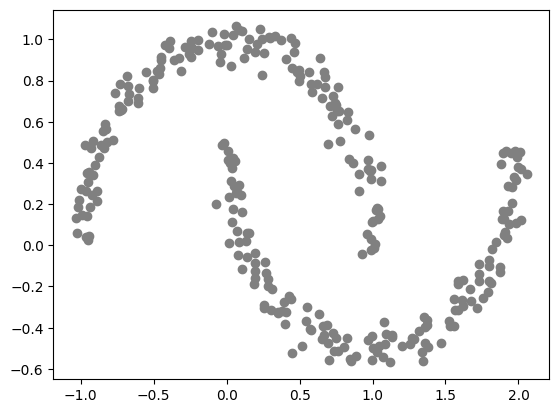

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the Data
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.05, random_state=63)

plt.scatter(X[:,0],X[:,1], c='grey')

In [49]:
# 1. Define the radius eps and the number of samples k
eps = 0.1
k = 4

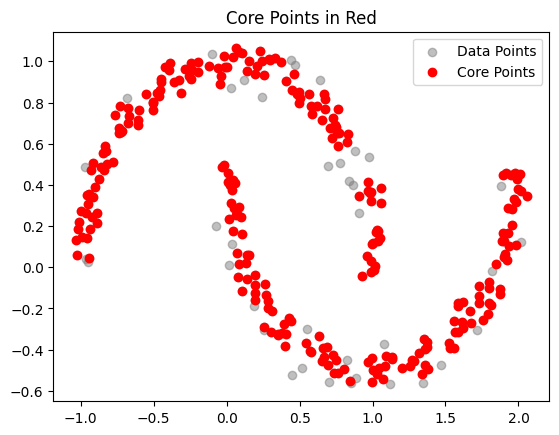

In [50]:
# 2. Identify core points
core_points = []

for i, point in enumerate(X):
    neighbors_found = 0
    for j, other_point in enumerate(X):
        if i == j:
            continue
        distance = np.sqrt(np.sum((point - other_point) ** 2))
        if distance < eps:
            neighbors_found += 1
            if neighbors_found >= k:          # Stop early once k neighbors found
                core_points.append(i)
                break

#print(f"Core point indices: {core_points}")

plt.scatter(X[:,0],X[:,1], c='grey', alpha=0.5, label='Data Points')
plt.scatter(X[core_points,0],X[core_points,1], c='red', label='Core Points')
plt.legend()
plt.title("Core Points in Red")
plt.show()

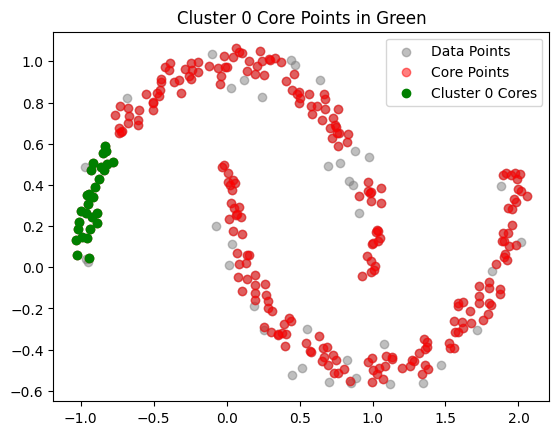

In [51]:
# 3. Form the first cluster
labels = {i: -1 for i in range(len(X))}   # -1 = unassigned
cluster_id = 0
clusters = []

# Randomly select the first core point and assign it to Cluster 0
first_core = np.random.choice(core_points)
labels[first_core] = cluster_id

# Use a queue to expand the cluster
queue = [first_core]
assigned_cores = {first_core}

while queue:
    current = queue.pop(0)
    for cp in core_points:
        if cp in assigned_cores:
            continue
        distance = np.sqrt(np.sum((X[current] - X[cp]) ** 2))
        if distance < eps:
            labels[cp] = cluster_id       # Merge into same cluster
            assigned_cores.add(cp)
            queue.append(cp)              # Check this new core point's neighbors too

# print(f"\nAfter Step 3 - Cluster 0 core points: {[i for i,l in labels.items() if l == 0]}")

plt.scatter(X[:,0],X[:,1], c='grey', alpha=0.5, label='Data Points')
plt.scatter(X[core_points,0],X[core_points,1], c='red', alpha=0.5,label='Core Points')
clusters.append(list(assigned_cores))
plt.scatter(X[clusters[0],0],X[clusters[0],1], c='green', label='Cluster 0 Cores')
plt.legend()
plt.title("Cluster 0 Core Points in Green")
plt.show()

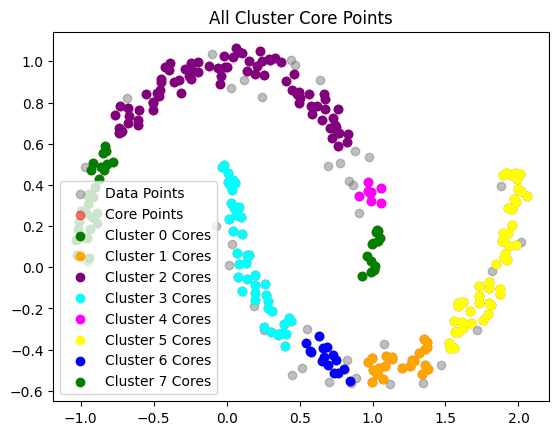

In [52]:
# 4. Create remaining clusters
remaining_cores = [cp for cp in core_points if cp not in assigned_cores]

plt.scatter(X[:,0],X[:,1], c='grey', alpha=0.5, label='Data Points')
plt.scatter(X[core_points,0],X[core_points,1], c='red', alpha=0.5,label='Core Points')
plt.scatter(X[clusters[0],0],X[clusters[0],1], c='green', label='Cluster 0 Cores')

color_cycle = ['green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'blue']

while remaining_cores:
    cluster_id += 1

    # Randomly select an unassigned core point to seed the new cluster
    seed = np.random.choice(remaining_cores)
    labels[seed] = cluster_id
    assigned_cores.add(seed)
    queue = [seed]

    while queue:
        current = queue.pop(0)
        for cp in core_points:
            if cp in assigned_cores:
                continue
            distance = np.sqrt(np.sum((X[current] - X[cp]) ** 2))
            if distance < eps:
                labels[cp] = cluster_id
                assigned_cores.add(cp)
                queue.append(cp)

    # Refresh the list of remaining unassigned core points
    remaining_cores = [cp for cp in core_points if cp not in assigned_cores]

    clusters.append([cp for cp in core_points if labels[cp] == cluster_id])
    plt.scatter(X[clusters[cluster_id],0],X[clusters[cluster_id],1], c=color_cycle[cluster_id % len(color_cycle)], label=f'Cluster {cluster_id} Cores')

# print(f"\nAfter Step 4 - All core point labels:")
# for cp in core_points:
#     print(f"  Point {cp}: Cluster {labels[cp]}")

plt.legend()
plt.title("All Cluster Core Points")
plt.show()

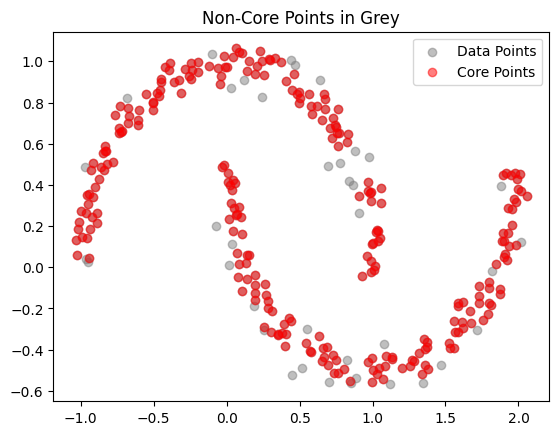

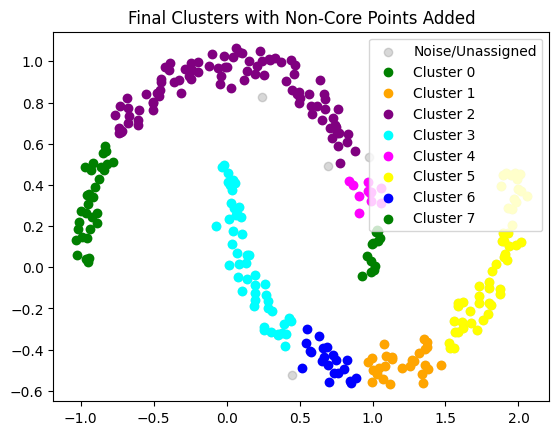

In [53]:
# 5. Add non-core points
non_core_points = [i for i in range(len(X)) if i not in core_points]

plt.scatter(X[:,0],X[:,1], c='grey', alpha=0.5, label='Data Points')
plt.scatter(X[core_points,0],X[core_points,1], c='red', alpha=0.5, label='Core Points')
plt.legend()
plt.title("Non-Core Points in Grey")
plt.show()

for i in non_core_points:
    closest_core = None
    closest_dist = float('inf')

    for cp in core_points:
        distance = np.sqrt(np.sum((X[i] - X[cp]) ** 2))
        if distance < eps and distance < closest_dist:
            closest_dist = distance
            closest_core = cp

    if closest_core is not None:
        labels[i] = labels[closest_core]
    else:
        labels[i] = -1    # Noise point

# Plot final clusters including non-core points
plt.scatter(X[:,0],X[:,1], c='grey', alpha=0.3, label='Noise/Unassigned')
for cid in range(cluster_id + 1):
    cluster_members = [i for i in range(len(X)) if labels[i] == cid]
    plt.scatter(X[cluster_members,0],X[cluster_members,1],
                c=color_cycle[cid % len(color_cycle)], label=f'Cluster {cid}')

plt.legend()
plt.title("Final Clusters with Non-Core Points Added")
plt.show()

# print(f"\nFinal labels for all points:")
# for i in range(len(X)):
#     status = "core" if i in core_points else "non-core"
#     cluster = labels[i] if labels[i] != -1 else "noise"
#     print(f"  Point {i} ({status}): Cluster {cluster}")

These were the results with $\epsilon = 0.1$ and $k=4$. But looking at the data, shouldn't we be able to make these just two clusters? Try again with the following parameters to see what happens:

* $\epsilon = 0.1$ and $k=3$
* $\epsilon = 0.1$ and $k=2$
* $\epsilon = 0.15$ and $k=4$

#### DBSCAN using Scikit-Learn 

In [66]:
from sklearn.cluster import DBSCAN

epsilon = 0.10
k = 4

dbscan = DBSCAN(eps=epsilon, min_samples=k)
y_predict = dbscan.fit_predict(X)

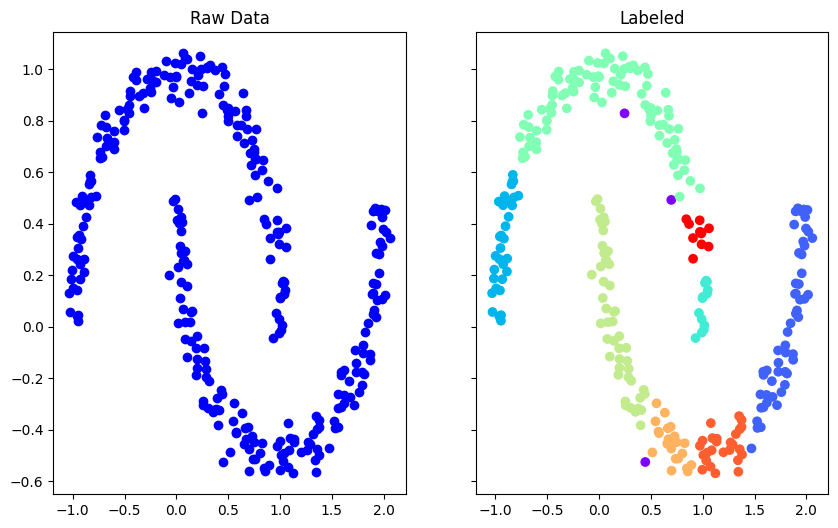

In [67]:
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(10,6))
ax1.set_title('Raw Data')
ax1.scatter(X[:,0],X[:,1],c='blue')
ax2.set_title("Labeled")
ax2.scatter(X[:,0],X[:,1],c=y_predict,cmap='rainbow')

## Limits of DBSCAN